In [1]:
from langgraph.graph import StateGraph , START, END
from typing import TypedDict





In [19]:
#create state
class batsmanState(TypedDict):
    runs: int
    balls : int
    sixes : int
    four : int

    sr : float
    bpb : float
    boundary_percent : float

    summary: str

In [21]:
def cal_sr(state:batsmanState):
    sr = (state['runs']/state['balls'])*100

    return {'sr':sr}

In [20]:
def cal_bpb(state:batsmanState):
   bpb = state['balls']/(state['sixes'] + state['four'])
   return {'bpb': bpb}

In [ ]:
def cal_bp(state:batsmanState):
    bp = ((state['four']*4) + (state['sixes']*6)) / state['runs']
    return {'bp',bp}

In [22]:
def summary(state:batsmanState):
    summary = f"""
    Strike-rate- {state['sr']},
    balls per boundary - {state['bpb']},
    boundary percentage - {state['boundary_percent']}  
"""

    return {'summary':summary}

In [23]:
# create graph 
graph = StateGraph(batsmanState)

# add node
graph.add_node('cal_sr',cal_sr )
graph.add_node('cal_bpb', cal_bpb)
graph.add_node('cal_bp', cal_bp)
graph.add_node('summary', summary)

# add edges
graph.add_edge(START,'cal_sr')
graph.add_edge(START,'cal_bpb')
graph.add_edge(START,'cal_bp')

graph.add_edge('cal_sr', 'summary')
graph.add_edge('cal_bpb', 'summary')
graph.add_edge('cal_bp', 'summary')
graph.add_edge('summary', END)


workflow = graph.compile()



In [24]:
res = workflow.invoke({
    'runs' : 100,
    'balls' : 50,
    'sixes' : 7,
    "four" : 5
})

In [27]:
res

{'runs': 100,
 'balls': 50,
 'sixes': 7,
 'four': 5,
 'sr': 200.0,
 'bpb': 4.166666666666667,
 'boundary_percent': 0.62,
 'summary': '\n    Strike-rate- 200.0,\n    balls per boundary - 4.166666666666667,\n    boundary percentage - 0.62  \n'}

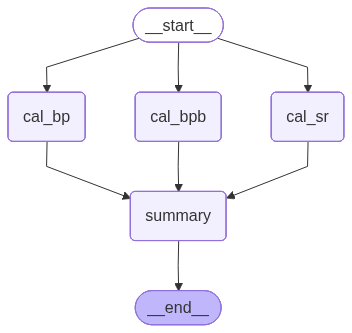

In [28]:

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())